# Panel Video → Textured 3D Panel (COLMAP `global_mapper`, formerly GLOMAP)

Pipeline: **video → frames → feature extraction/matching → global SfM (`colmap global_mapper`) → camera-based plane alignment → point cloud → textured flat panel**.

GLOMAP has been merged directly into COLMAP as of COLMAP 4.x — there's no separate `glomap` binary to install anymore. Its global SfM solver is now the `colmap global_mapper` command: it estimates all camera rotations and positions jointly instead of growing the reconstruction incrementally one image at a time like `colmap mapper` does.

**Important finding from testing on this panel's footage:** the per-point *depth* (distance along the camera's viewing axis) turned out to be far noisier than the true out-of-plane thickness of the panel — noisier, in fact, than the panel's real in-plane dimensions. A naive PCA-based plane fit (treating the point cloud's least-variance axis as "the normal") picks up this noise and gets the orientation completely wrong, and meshing the raw points then produces spiky, chaotic geometry instead of a flat surface — colors were always fine, the *geometry* wasn't. The fix: build the plane orientation from **camera geometry** (average viewing direction + camera-translation axis) instead of from the noisy points themselves, and — since per-point depth can't be trusted anyway — skip meshing the noisy points altogether. Instead, this notebook bakes the actual source video frame onto a flat rectangle as a texture, using each point's known 3D position and the camera's real pose to look up real pixels. Output is a textured flat panel (`.obj`/`.glb`) with full photographic color, not a sparse per-point splatter.

## 0. System dependencies

`colmap` and `ffmpeg` install via Homebrew. GLOMAP's global SfM solver ships as part of COLMAP itself (the `global_mapper` command) since COLMAP 4.x — no separate install needed, just a recent enough COLMAP version.

In [1]:
import shutil, subprocess

def check_tool(name, args=("-h",)):
    path = shutil.which(name)
    if path is None:
        print(f"✗ {name} not found on PATH")
        return False
    print(f"✓ {name} → {path}")
    return True

have_colmap = check_tool("colmap")
have_ffmpeg = check_tool("ffmpeg", ("-version",))

if not (have_colmap and have_ffmpeg):
    print("\nMissing colmap/ffmpeg — install with:\n\n    brew install colmap ffmpeg\n")

if have_colmap:
    result = subprocess.run(["colmap", "help"], capture_output=True, text=True)
    have_global_mapper = "global_mapper" in result.stdout
    print(f"{'✓' if have_global_mapper else '✗'} colmap global_mapper "
          f"{'available' if have_global_mapper else 'NOT available — upgrade: brew upgrade colmap (needs COLMAP 4.x+)'}")

✓ colmap → /opt/homebrew/bin/colmap
✓ ffmpeg → /opt/homebrew/bin/ffmpeg


✓ colmap global_mapper available


In [2]:
!pip install -q pycolmap trimesh opencv-python-headless numpy matplotlib tqdm

## 1. Config

In [3]:
from pathlib import Path

# ── INPUT ───────────────────────────────────────────────
VIDEO_PATH = Path("media/short.mp4")   # ← change this

# ── WORKSPACE ───────────────────────────────────────────────
WORKSPACE  = Path("glomap_ws")   # separate from colmap_ws (the earlier incremental-mapper attempt)
IMAGES_DIR = WORKSPACE / "images"
SPARSE_DIR = WORKSPACE / "sparse"
DATABASE   = WORKSPACE / "database.db"

for d in (IMAGES_DIR, SPARSE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ── FRAME EXTRACTION ──────────────────────────────────────
EXTRACT_FPS      = 6      # frames/sec pulled from the video — raise for denser overlap, lower for faster runs
BLUR_THRESHOLD   = 100.0  # drop frames blurrier than this (variance of Laplacian); set to None to disable
CLEAR_OLD_FRAMES = True   # True = wipe frames + database + reconstruction before this run

# ── COLMAP feature extraction/matching (global_mapper consumes this database) ──
CAMERA_MODEL = "OPENCV"     # single-lens distortion model; try SIMPLE_RADIAL if calibration looks off
EXHAUSTIVE_THRESHOLD = 150  # frame count below which exhaustive_matcher is used instead of sequential_matcher —
                            # worth it at this scale, and more robust against repetitive texture (e.g. the
                            # panel's circle grid) than only matching temporal neighbors.

# ── GLOBAL SFM (colmap global_mapper) ───────────────────────────────────────
# global_mapper warns if fewer than half your images have focal-length priors (common for phone/
# screen-recorded video with no EXIF) and suggests running `colmap view_graph_calibrator` on the
# database first. Tested on this panel's data: it didn't meaningfully change results either way —
# leave off by default, flip on to try it if global_mapper's own warning shows up for your footage.
RUN_VIEW_GRAPH_CALIBRATION = False

# Extra flags passed straight to `colmap global_mapper` (run `colmap global_mapper -h` to see the
# full option list). Tested on this panel's data: freezing focal length + distortion refinement
# during bundle adjustment gave a visibly better (though not perfect) reconstruction.
GLOBAL_MAPPER_EXTRA_ARGS = [
    "--GlobalMapper.ba_refine_focal_length", "0",
    "--GlobalMapper.ba_refine_extra_params", "0",
]

# ── POINT CLOUD FILTERING ────────────────────────────────────────────
MIN_TRACK_LENGTH = 3     # keep only points triangulated from at least this many images
MAX_REPROJ_ERROR = 2.0   # keep only points with reprojection error under this many pixels

# ── PANEL ISOLATION ──────────────────────────────────────────────────────
# COLMAP registers keypoints anywhere there's texture, including background (trees, sky, window
# frame behind the panel) — these need to be excluded before building a flat panel crop. Inspect
# the "camera-aligned XY scatter" plot further down (colored by each point's real RGB — panel
# points are dark, background is green/blue) and set bounds that enclose only the panel itself.
# None = no bound on that side. Values below are tuned for this specific clip's aligned frame —
# re-inspect the scatter plot and re-tune if you use different footage.
PANEL_X_RANGE = (-9.8, -1.0)
PANEL_Y_RANGE = (None, None)

print(f"Video: {VIDEO_PATH}  (exists: {VIDEO_PATH.exists()})")
print(f"Workspace: {WORKSPACE.resolve()}")

Video: media/short.mp4  (exists: True)
Workspace: /Users/az/Documents/GitHub/dobby/glomap_ws


## 2. Extract frames from video (ffmpeg)

For good SfM results you want 70-90% overlap between consecutive frames and minimal motion blur. `EXTRACT_FPS` controls overlap.

In [4]:
def next_frame_index(out_dir):
    existing = sorted(out_dir.glob("frame_*.jpg"))
    if not existing:
        return 0
    return int(existing[-1].stem.split("_")[1]) + 1

def extract_frames_ffmpeg(video_path, out_dir, fps=6, clear_existing=True):
    if clear_existing:
        for f in out_dir.glob("frame_*.jpg"):
            f.unlink()
        if DATABASE.exists():
            DATABASE.unlink()
        shutil.rmtree(SPARSE_DIR, ignore_errors=True)
        SPARSE_DIR.mkdir(parents=True, exist_ok=True)
        print("Cleared previous frames + database + reconstruction.")
        start = 0
    else:
        start = next_frame_index(out_dir)
        print(f"Keeping existing frames — appending new ones starting at index {start}.")

    pattern = str(out_dir / "frame_%05d.jpg")
    cmd = ["ffmpeg", "-y", "-i", str(video_path), "-vf", f"fps={fps}",
           "-qscale:v", "2", "-start_number", str(start), pattern]
    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr[-2000:])
        raise RuntimeError("ffmpeg failed — see stderr above")
    frames = sorted(out_dir.glob("frame_*.jpg"))
    print(f"Extracted → {out_dir} (total frames now: {len(frames)})")
    return frames

frame_paths = extract_frames_ffmpeg(VIDEO_PATH, IMAGES_DIR, EXTRACT_FPS, clear_existing=CLEAR_OLD_FRAMES)

Cleared previous frames + database + reconstruction.
Running: ffmpeg -y -i media/short.mp4 -vf fps=6 -qscale:v 2 -start_number 0 glomap_ws/images/frame_%05d.jpg


Extracted → glomap_ws/images (total frames now: 66)


## 3. Drop blurry frames (optional)

Scores each frame by variance of Laplacian (a sharpness proxy) and drops the blurriest ones.

In [5]:
import cv2
import numpy as np

def blur_score(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    return cv2.Laplacian(img, cv2.CV_64F).var()

if BLUR_THRESHOLD is not None:
    kept, dropped = [], []
    for p in frame_paths:
        (kept if blur_score(p) >= BLUR_THRESHOLD else dropped).append(p)
    for p in dropped:
        p.unlink()
    print(f"Dropped {len(dropped)} blurry frames, kept {len(kept)}")
    frame_paths = kept
else:
    print("Blur filtering disabled")

Dropped 0 blurry frames, kept 66


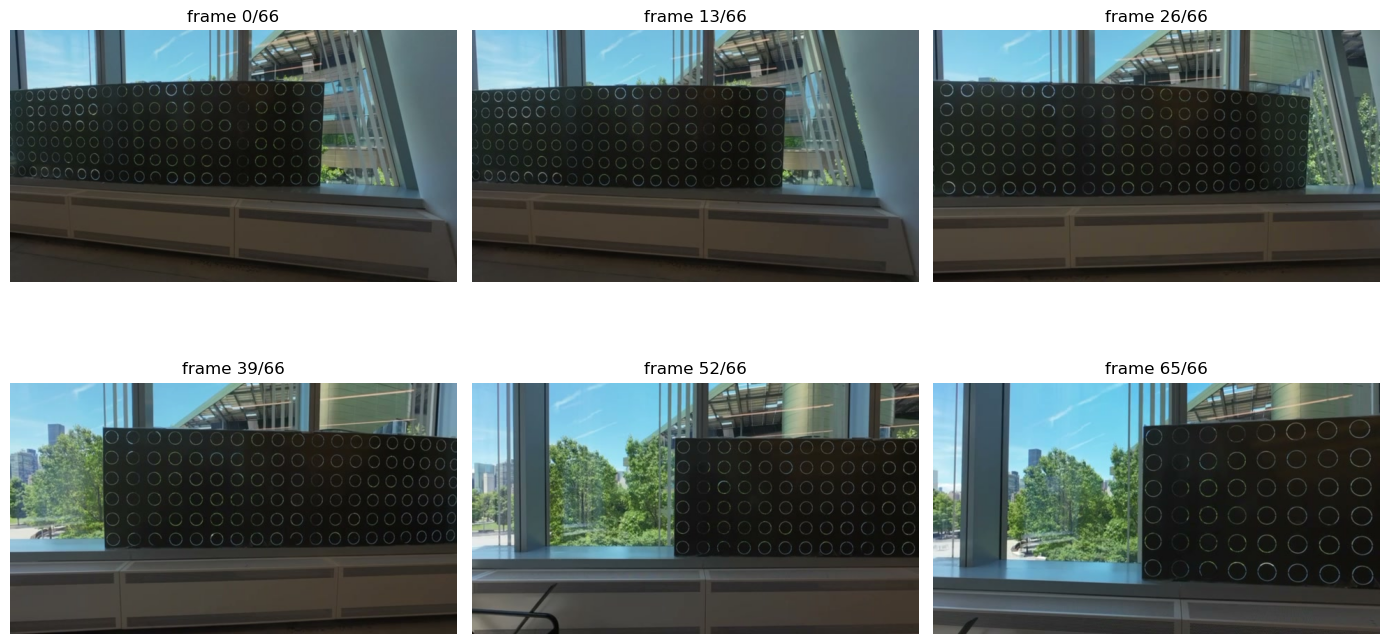

In [6]:
import matplotlib.pyplot as plt

sample_idx = np.linspace(0, len(frame_paths) - 1, 6).astype(int)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, i in zip(axes.flat, sample_idx):
    img = cv2.cvtColor(cv2.imread(str(frame_paths[i])), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"frame {i}/{len(frame_paths)}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Feature extraction + matching (COLMAP)

GLOMAP doesn't do its own feature detection — it consumes a COLMAP database. Small frame counts (a pan around a static object, not a huge unordered photo set) benefit from exhaustive matching, which also holds up better than sequential matching against the panel's repetitive circle-grid texture.

In [7]:
def run(cmd):
    cmd = [str(c) for c in cmd]
    print("$", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stdout[-3000:])
        print(result.stderr[-3000:])
        raise RuntimeError(f"Command failed: {cmd[:2]}")
    return result

run([
    "colmap", "feature_extractor",
    "--database_path", DATABASE,
    "--image_path", IMAGES_DIR,
    "--ImageReader.single_camera", "1",
    "--ImageReader.camera_model", CAMERA_MODEL,
])
print("Feature extraction done.")

$ colmap feature_extractor --database_path glomap_ws/database.db --image_path glomap_ws/images --ImageReader.single_camera 1 --ImageReader.camera_model OPENCV


Feature extraction done.


In [8]:
if len(frame_paths) <= EXHAUSTIVE_THRESHOLD:
    matcher_cmd = ["colmap", "exhaustive_matcher", "--database_path", DATABASE]
    print(f"{len(frame_paths)} frames — using exhaustive_matcher.")
else:
    matcher_cmd = ["colmap", "sequential_matcher", "--database_path", DATABASE,
                   "--SequentialMatching.overlap", "10"]
    print(f"{len(frame_paths)} frames — using sequential_matcher.")

run(matcher_cmd)
print("Matching done.")

66 frames — using exhaustive_matcher.
$ colmap exhaustive_matcher --database_path glomap_ws/database.db


Matching done.


## 5. Global SfM (`colmap global_mapper`)

Replaces `colmap mapper`'s incremental reconstruction with COLMAP's global solver (formerly the standalone GLOMAP project), reading the same database and writing a COLMAP-format sparse model.

In [9]:
if RUN_VIEW_GRAPH_CALIBRATION:
    run(["colmap", "view_graph_calibrator", "--database_path", DATABASE])
    print("View graph calibration done.")
else:
    print("Skipping view graph calibration (RUN_VIEW_GRAPH_CALIBRATION = False).")

Skipping view graph calibration (RUN_VIEW_GRAPH_CALIBRATION = False).


In [10]:
import pycolmap

run([
    "colmap", "global_mapper",
    "--database_path", DATABASE,
    "--image_path", IMAGES_DIR,
    "--output_path", SPARSE_DIR,
] + GLOBAL_MAPPER_EXTRA_ARGS)

def locate_sparse_model(output_path):
    """global_mapper can write directly into output_path, or into numbered subfolders like
    colmap's incremental mapper does for disconnected components — handle both,
    and if there are multiple, pick the one with the most registered images
    (never blindly take the first, that's what produced the broken 2-camera
    fragment in the earlier colmap-mapper run)."""
    def is_model_dir(p):
        return (p / "cameras.bin").exists() or (p / "cameras.txt").exists()

    if is_model_dir(output_path):
        return output_path

    candidates = [p for p in output_path.iterdir() if p.is_dir() and is_model_dir(p)]
    if not candidates:
        raise RuntimeError(f"No reconstruction found under {output_path}")
    if len(candidates) == 1:
        return candidates[0]

    sizes = {p: pycolmap.Reconstruction(str(p)).num_reg_images() for p in candidates}
    print("Registered images per model:", {p.name: n for p, n in sizes.items()})
    best = max(sizes, key=sizes.get)
    print(f"Using {best.name} ({sizes[best]} registered images)")
    return best

SPARSE_MODEL = locate_sparse_model(SPARSE_DIR)
print(f"Sparse model → {SPARSE_MODEL}")

$ colmap global_mapper --database_path glomap_ws/database.db --image_path glomap_ws/images --output_path glomap_ws/sparse --GlobalMapper.ba_refine_focal_length 0 --GlobalMapper.ba_refine_extra_params 0


Sparse model → glomap_ws/sparse/0


## 6. Load reconstruction + camera-based plane alignment

Builds the world→aligned transform from **camera geometry**, not point-cloud PCA. Camera poses are far better constrained than per-point depth for a narrow-baseline capture like this one — testing showed the points' own least-variance axis is *not* a reliable stand-in for the panel's true surface normal (see the note at the top of this notebook), so: normal = average camera viewing direction, pan axis = PCA on camera *centers* (not the points), third axis completes a right-handed frame.

Reconstruction:
	num_rigs = 1
	num_cameras = 1
	num_frames = 66
	num_reg_frames = 66
	num_images = 66
	num_points3D = 3846
	num_observations = 33636
	mean_track_length = 8.74571
	mean_observations_per_image = 509.636
	mean_reprojection_error = 0.770107
View-alignment score (1.0 = perfectly frontal): min=0.92 mean=0.97 max=1.00


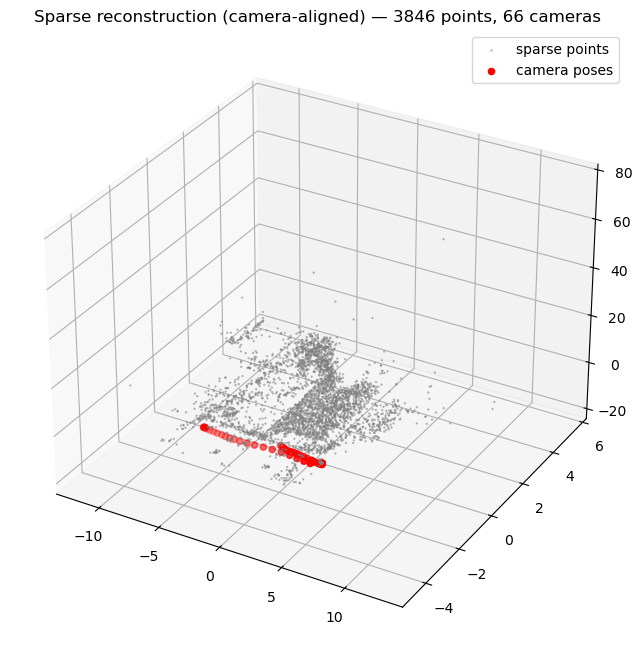

In [11]:
recon = pycolmap.Reconstruction(str(SPARSE_MODEL))
print(recon.summary())

def camera_center(image):
    if hasattr(image, "projection_center"):
        return image.projection_center()
    return image.cam_from_world.inverse().translation

def camera_frame_alignment(recon):
    """Build a rotation matrix from camera geometry rather than point-cloud PCA.

    Z axis (surface normal) = average camera viewing direction — every frame looks at roughly
    the same subject, so this approximates "straight at the panel".
    X axis (pan direction)  = dominant direction of camera *translation* (PCA on camera centers,
    which SfM constrains far better than individual point depth), projected orthogonal to Z.
    Y axis completes a right-handed frame.
    """
    cams = np.array([camera_center(img) for img in recon.images.values()])
    viewdirs = np.array([img.viewing_direction() for img in recon.images.values()])

    z_axis = viewdirs.mean(axis=0)
    z_axis /= np.linalg.norm(z_axis)

    cam_centroid = cams.mean(axis=0)
    cam_cov = (cams - cam_centroid).T @ (cams - cam_centroid)
    eigvals, eigvecs = np.linalg.eigh(cam_cov)
    pan_axis = eigvecs[:, np.argmax(eigvals)]
    pan_axis = pan_axis - np.dot(pan_axis, z_axis) * z_axis  # orthogonalize against the normal
    pan_axis /= np.linalg.norm(pan_axis)
    x_axis = pan_axis
    y_axis = np.cross(z_axis, x_axis)
    y_axis /= np.linalg.norm(y_axis)

    R = np.stack([x_axis, y_axis, z_axis])
    if np.linalg.det(R) < 0:
        R[1] *= -1
    return R, cams

def apply_transform(T, pts):
    return (T[:3, :3] @ pts.T).T + T[:3, 3]

points = np.array([p.xyz for p in recon.points3D.values()])
R, cams = camera_frame_alignment(recon)
point_centroid = np.median(points, axis=0)  # median, not mean -- robust to the gross outlier points SfM occasionally produces

ALIGNMENT = np.eye(4)
ALIGNMENT[:3, :3] = R
ALIGNMENT[:3, 3] = -R @ point_centroid

points_aligned = apply_transform(ALIGNMENT, points)
cams_aligned = apply_transform(ALIGNMENT, cams)

# Sanity check: every camera's viewing direction should now be close to (0, 0, ±1) if the
# alignment is physically correct — this was ~0.2 (badly wrong) with the old PCA-on-points method.
view_scores = [abs(np.dot(R, img.viewing_direction())[2]) for img in recon.images.values()]
print(f"View-alignment score (1.0 = perfectly frontal): min={min(view_scores):.2f} "
      f"mean={np.mean(view_scores):.2f} max={max(view_scores):.2f}")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(points_aligned[:, 0], points_aligned[:, 1], points_aligned[:, 2], s=0.5, c="gray", alpha=0.5, label="sparse points")
ax.scatter(cams_aligned[:, 0], cams_aligned[:, 1], cams_aligned[:, 2], s=20, c="red", label="camera poses")
ax.set_title(f"Sparse reconstruction (camera-aligned) — {len(points)} points, {len(cams)} cameras")
ax.legend()
plt.show()

## 7. Filtered point cloud export

Raw SfM points always include noisy outliers — low track length or high reprojection error. Filter before trusting the shape, then export directly as a colored `.ply` point cloud. Also plots a straight-down (X,Y) view colored by each point's real color — use this to pick `PANEL_X_RANGE`/`PANEL_Y_RANGE` in the config cell (panel points are dark; background trees/sky are green/blue).

Keeping 3738/3846 points after filtering (MIN_TRACK_LENGTH=3, MAX_REPROJ_ERROR=2.0)
Gross outlier removal: kept 3736/3738


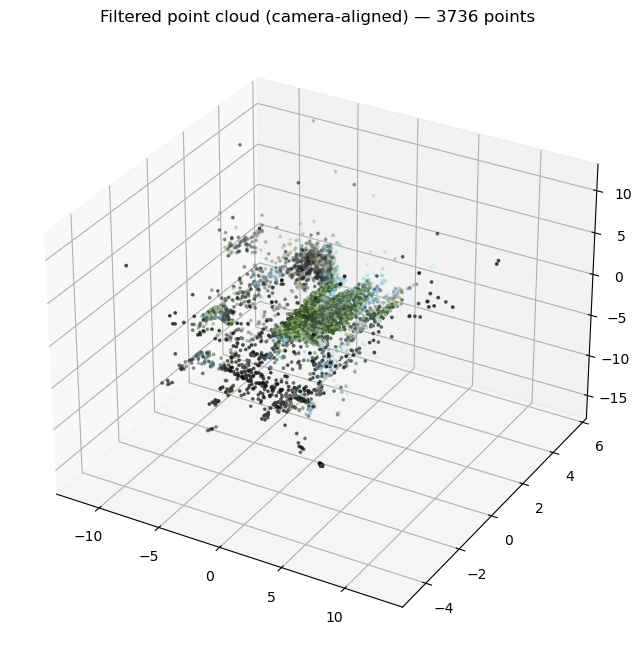

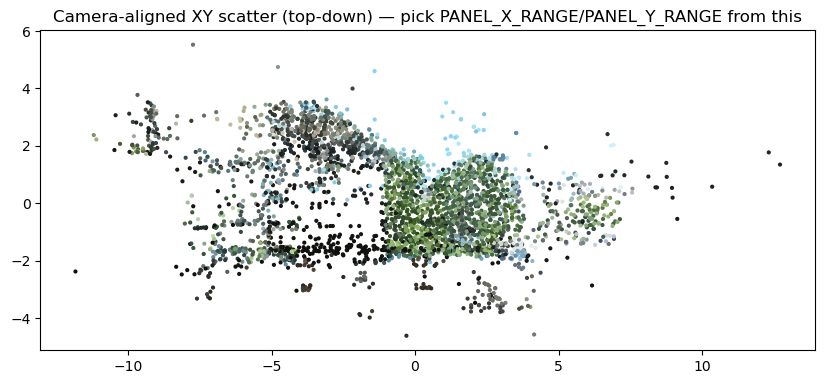

X/Y std: 2.766   Z std: 4.126   Z/XY ratio: 149.16%  (expected to be large -- see above)


Point cloud saved → glomap_ws/panel_pointcloud.ply


In [12]:
good_ids = [
    pid for pid, p in recon.points3D.items()
    if p.track.length() >= MIN_TRACK_LENGTH and p.error <= MAX_REPROJ_ERROR
]
print(f"Keeping {len(good_ids)}/{len(recon.points3D)} points after filtering "
      f"(MIN_TRACK_LENGTH={MIN_TRACK_LENGTH}, MAX_REPROJ_ERROR={MAX_REPROJ_ERROR})")

filtered_xyz = np.array([recon.points3D[pid].xyz for pid in good_ids])
filtered_rgb = np.array([recon.points3D[pid].color for pid in good_ids])  # uint8, 0-255
filtered_xyz_aligned = apply_transform(ALIGNMENT, filtered_xyz)

# Gross-outlier removal: SfM occasionally puts a point wildly far from everything else (bad
# triangulation from a near-degenerate view pair). A single such point can dominate a bounding
# box or a plot's axis limits even though it's 1-in-thousands, so drop anything far from the
# median position before using this cloud for anything downstream.
median_pos = np.median(filtered_xyz_aligned, axis=0)
dist_from_median = np.linalg.norm(filtered_xyz_aligned - median_pos, axis=1)
gross_outlier_mask = dist_from_median <= 6.0 * np.median(dist_from_median)
print(f"Gross outlier removal: kept {gross_outlier_mask.sum()}/{len(filtered_xyz_aligned)}")
filtered_xyz_aligned = filtered_xyz_aligned[gross_outlier_mask]
filtered_rgb = filtered_rgb[gross_outlier_mask]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(filtered_xyz_aligned[:, 0], filtered_xyz_aligned[:, 1], filtered_xyz_aligned[:, 2],
           s=3, c=filtered_rgb / 255.0)
ax.set_title(f"Filtered point cloud (camera-aligned) — {len(filtered_xyz_aligned)} points")
plt.show()

# Straight-down (X,Y) view, colored by real point color -- use this to set PANEL_X_RANGE /
# PANEL_Y_RANGE in the config cell so the textured-panel step below only uses panel points.
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(filtered_xyz_aligned[:, 0], filtered_xyz_aligned[:, 1], s=4, c=filtered_rgb / 255.0)
ax.set_aspect("equal")
ax.set_title("Camera-aligned XY scatter (top-down) — pick PANEL_X_RANGE/PANEL_Y_RANGE from this")
plt.show()

# Depth (Z) is expected to still show real scatter here even after all this filtering -- per-point
# depth from this capture is inherently noisy (see the note at the top of the notebook). That's
# why the next section bakes a texture from the real video instead of trusting per-point depth.
xy_std = filtered_xyz_aligned[:, :2].std()
z_std = filtered_xyz_aligned[:, 2].std()
print(f"X/Y std: {xy_std:.3f}   Z std: {z_std:.3f}   Z/XY ratio: {z_std / xy_std:.2%}  (expected to be large -- see above)")

import trimesh

POINTCLOUD_PATH = WORKSPACE / "panel_pointcloud.ply"
trimesh.points.PointCloud(filtered_xyz_aligned, colors=filtered_rgb).export(str(POINTCLOUD_PATH))
print(f"Point cloud saved → {POINTCLOUD_PATH}")

## 8. Textured flat panel (orthorectified from source video)

Per-point depth from this capture is too noisy to use directly as mesh relief — a 2D Delaunay height-field over it produces spiky, chaotic geometry, not a clean surface (verified directly: even after outlier removal, its faces looked like a jagged mountain range, not a panel). Since the panel is physically flat, sidestep per-point depth entirely instead of trying to smooth it away:

1. Crop to panel-only points using `PANEL_X_RANGE`/`PANEL_Y_RANGE` (from the scatter plot above).
2. Build a flat rectangle sized to that extent, at Z=0 in the camera-aligned frame.
3. Pick the source frame whose camera looked most nearly straight at the panel.
4. For every point on the rectangle, project its known 3D position through that camera's real pose (`image.project_point`) to find the matching pixel, and bake those real pixels into a texture image.

Result: full photographic detail and color (the actual video frame, not ~3.7k sparse vertex colors) on a perfectly flat, non-spiky surface.

In [13]:
def in_range(values, rng):
    lo, hi = rng
    mask = np.ones(len(values), dtype=bool)
    if lo is not None:
        mask &= values >= lo
    if hi is not None:
        mask &= values <= hi
    return mask

panel_mask = in_range(filtered_xyz_aligned[:, 0], PANEL_X_RANGE) & in_range(filtered_xyz_aligned[:, 1], PANEL_Y_RANGE)
panel_pts = filtered_xyz_aligned[panel_mask]
print(f"Panel-only points: {len(panel_pts)}/{len(filtered_xyz_aligned)}")
if len(panel_pts) < 20:
    raise RuntimeError("Almost no points left after PANEL_X_RANGE/PANEL_Y_RANGE cropping -- "
                        "re-check the scatter plot above and widen the range.")

x_lo, x_hi = np.percentile(panel_pts[:, 0], [1, 99])
y_lo, y_hi = np.percentile(panel_pts[:, 1], [1, 99])
print(f"Panel extent: X=({x_lo:.2f}, {x_hi:.2f})  Y=({y_lo:.2f}, {y_hi:.2f})")

# Most fronto-parallel source image: viewing direction closest to the alignment's Z axis.
best_image, best_score = None, -1
for img in recon.images.values():
    score = abs(np.dot(R, img.viewing_direction())[2])
    if score > best_score:
        best_score, best_image = score, img
print(f"Best fronto-parallel frame: {best_image.name} (score {best_score:.3f}, 1.0 = perfectly frontal)")

Panel-only points: 1495/3736
Panel extent: X=(-9.35, -1.03)  Y=(-2.96, 3.45)
Best fronto-parallel frame: frame_00062.jpg (score 1.000, 1.0 = perfectly frontal)


Texture coverage: 87.6% of the panel rectangle fell inside frame_00062.jpg


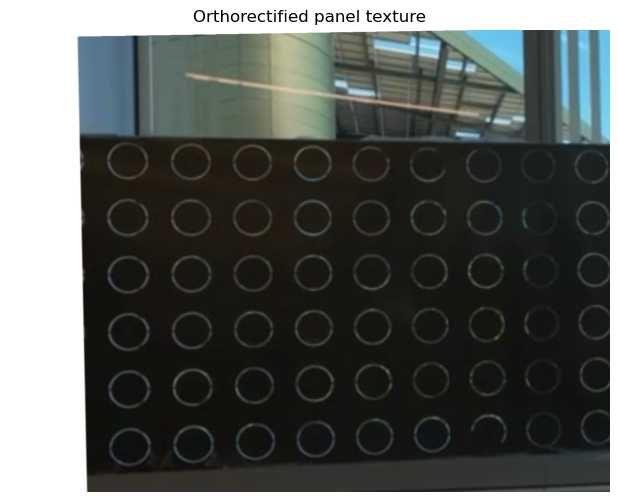

Texture saved → glomap_ws/panel_texture.png


In [14]:
import cv2

TEXTURE_WIDTH = 1600
world_w, world_h = x_hi - x_lo, y_hi - y_lo
texture_height = int(TEXTURE_WIDTH * world_h / world_w)

# Grid of plane points (Z=0, camera-aligned frame) spanning the panel extent, mapped back to
# original recon-frame coordinates so they can be projected through the chosen camera's real pose.
xs = np.linspace(x_lo, x_hi, TEXTURE_WIDTH)
ys = np.linspace(y_hi, y_lo, texture_height)  # flip so texture row 0 = top = y_hi
gx, gy = np.meshgrid(xs, ys)
grid_aligned = np.stack([gx.ravel(), gy.ravel(), np.zeros(gx.size)], axis=1)
grid_world = (R.T @ grid_aligned.T).T + point_centroid  # inverse of ALIGNMENT's rotation+translation

frame = cv2.imread(str(IMAGES_DIR / best_image.name))
h, w = frame.shape[:2]
pix = np.full((grid_world.shape[0], 2), np.nan)
for i, p in enumerate(grid_world):
    proj = best_image.project_point(p)
    if proj is not None:
        pix[i] = proj

valid = ~np.isnan(pix[:, 0])
in_bounds = valid & (pix[:, 0] >= 0) & (pix[:, 0] < w) & (pix[:, 1] >= 0) & (pix[:, 1] < h)
print(f"Texture coverage: {in_bounds.mean():.1%} of the panel rectangle fell inside {best_image.name}")

map_x = pix[:, 0].reshape(texture_height, TEXTURE_WIDTH).astype(np.float32)
map_y = pix[:, 1].reshape(texture_height, TEXTURE_WIDTH).astype(np.float32)
mask_img = in_bounds.reshape(texture_height, TEXTURE_WIDTH)
map_x[~mask_img] = -1
map_y[~mask_img] = -1

texture_bgr = cv2.remap(frame, map_x, map_y, interpolation=cv2.INTER_LINEAR,
                         borderMode=cv2.BORDER_CONSTANT, borderValue=(255, 255, 255))

TEXTURE_PATH = WORKSPACE / "panel_texture.png"
cv2.imwrite(str(TEXTURE_PATH), texture_bgr)

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(texture_bgr, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Orthorectified panel texture")
plt.show()
print(f"Texture saved → {TEXTURE_PATH}")

In [15]:
from PIL import Image

# Flat quad (Z=0 in the camera-aligned frame) spanning the panel extent, UV-mapped to the baked texture.
quad_vertices = np.array([
    [x_lo, y_lo, 0.0],
    [x_hi, y_lo, 0.0],
    [x_hi, y_hi, 0.0],
    [x_lo, y_hi, 0.0],
])
quad_uv = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0],
])
quad_faces = np.array([[0, 1, 2], [0, 2, 3]])

# doubleSided=True: the flat quad's face winding points its normal along the alignment's Z axis
# (away from where the cameras were, since Z = average camera *viewing* direction, not the
# direction back toward the cameras). Single-sided materials get back-face culled by glTF/Blender,
# so without this the panel is invisible from the "natural" viewing angle -- looks blank/see-through
# until you orbit around to the far side. Double-siding sidesteps needing to get winding exactly right.
material = trimesh.visual.material.PBRMaterial(baseColorTexture=Image.open(TEXTURE_PATH), doubleSided=True)
visual = trimesh.visual.TextureVisuals(uv=quad_uv, material=material)
panel_mesh = trimesh.Trimesh(vertices=quad_vertices, faces=quad_faces, visual=visual, process=False)
print(panel_mesh)
panel_mesh.show()

PANEL_OBJ = WORKSPACE / "panel_textured.obj"
PANEL_GLB = WORKSPACE / "panel_textured.glb"
panel_mesh.export(str(PANEL_OBJ))
panel_mesh.export(str(PANEL_GLB))
print(f"Textured flat panel exported:\n  {PANEL_OBJ}\n  {PANEL_GLB}")

<trimesh.Trimesh(vertices.shape=(4, 3), faces.shape=(2, 3))>


Textured flat panel exported:
  glomap_ws/panel_textured.obj
  glomap_ws/panel_textured.glb


---
## Troubleshooting

| Symptom | Fix |
|---|---|
| `colmap global_mapper` not found | Need COLMAP 4.x+ — `brew upgrade colmap` |
| Warning about "less than 50% of cameras have prior focal lengths" | Try `RUN_VIEW_GRAPH_CALIBRATION = True` in the config cell — didn't change results on this panel's data, but may help on footage with worse focal-length priors |
| Very few points / images registered | Raise `EXTRACT_FPS`; check `BLUR_THRESHOLD` isn't over-filtering; confirm the pan has real sideways parallax, not just rotation in place |
| "View-alignment score" (cell 6) is low, not close to 1.0 | The camera-based alignment assumes most frames look roughly at the same subject — if the capture path is unusual (e.g. orbiting all the way around), this assumption breaks down |
| Textured panel includes background (trees/window) | Re-inspect the "camera-aligned XY scatter" plot and tighten `PANEL_X_RANGE`/`PANEL_Y_RANGE` in the config cell |
| Texture coverage is low / has blank (white) patches | The panel extent extends beyond what the chosen frame could see — lower `TEXTURE_WIDTH`'s implied extent by tightening `PANEL_X_RANGE`/`PANEL_Y_RANGE`, or pick a different image manually if `best_image` isn't actually the most complete view |
| Point cloud still noisy after filtering | Lower `MAX_REPROJ_ERROR` / raise `MIN_TRACK_LENGTH` in the config cell |
| Object isn't actually planar (has real 3D structure, not just a flat panel) | The flat-quad approach here assumes a mostly-flat subject — for genuinely 3D objects, per-point depth would need to be trustworthy enough to mesh, which wasn't the case for this capture; a full turntable-style capture with more angular diversity per point would be a better starting point |
| Feature matching slow | Lower `EXTRACT_FPS`, or reduce frame resolution in the ffmpeg extraction cell (`-vf fps=X,scale=1280:-1`) |